<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [5]:
# Your code here
df_c=pd.read_csv('./data/College.csv')
df_c.head(1)

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60


In [6]:
df_c.rename(columns={'Unnamed: 0':'Collage'},inplace=True)

#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [7]:
# Your code here
df_c.shape

(777, 19)

In [8]:
df_c.dtypes

Collage            str
Private            str
Apps             int64
Accept           int64
Enroll           int64
Top10perc        int64
Top25perc        int64
F.Undergrad      int64
P.Undergrad      int64
Outstate         int64
Room.Board       int64
Books            int64
Personal         int64
PhD                str
Terminal         int64
S.F.Ratio      float64
perc.alumni      int64
Expend           int64
Grad.Rate        int64
dtype: object

In [9]:
df_c.isna().sum()

Collage        0
Private        0
Apps           0
Accept         0
Enroll         0
Top10perc      0
Top25perc      0
F.Undergrad    0
P.Undergrad    0
Outstate       0
Room.Board     0
Books          0
Personal       0
PhD            0
Terminal       0
S.F.Ratio      0
perc.alumni    0
Expend         0
Grad.Rate      0
dtype: int64

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [10]:
# Your code here
df_c['PhD'].unique()

<ArrowStringArray>
[ '70',  '29',  '53',  '92',  '76',   '?',  '90',  '89',  '79',  '40',  '82',
  '73',  '60',  '36',  '78',  '48',  '62',  '69',  '83',  '55',  '88',  '57',
  '93',  '85',  '65',  '66',  '81',  '59',  '58',  '68',  '98',  '71',  '74',
  '61',  '35',  '87',  '80',  '63',  '75',  '39',  '99', '100',  '95',  '77',
  '72',  '64',  '10',  '86',  '22',  '50',  '41',   '8',  '67',  '94',  '56',
  '46',  '54',  '84',  '97',  '51',  '42',  '49',  '52',  '43',  '37',  '45',
  '47',  '91',  '31',  '96',  '34',  '33',  '44',  '32',  '14', '103',  '26',
  '16']
Length: 78, dtype: str

In [11]:
df_c.replace({'PhD':'?'},None,inplace=True);

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [12]:
# Your code here
df_c['Grad.Rate'].unique()

array([ 60,  56,  54,  59,  15,  55,  63,  73,  80,  52,  76,  74,  68,
        69, 100,  46,  34,  48,  70,  65,  88,  58,  71,  85,  79,  91,
        72,  84,  49,  82,  35,  51,  75,  53,  96,  67,  18,  33,  97,
        89,  93,  78,  83,  61,  81,  64,  62, 118,  24,  66,  47,  50,
        21,  87,  77,  43,  95,  37,  99,  45,  42,  98,  94,  38,  86,
        44,  22,  57,  29,  36,  39,  40,  26,  90,  92,  32,  27,  41,
        31,  10,  30])

**replacing the 118 with the median grad rate, since the 118 considerd as outlier**

In [13]:
df_c.replace({'Grad.Rate':118},df_c['Grad.Rate'].median(),inplace=True);

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [14]:
%%writefile myutils.py
import pandas as pd
def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 
    results=[]

    numeric_columns=df.select_dtypes(include='number').columns

    for i in numeric_columns:
        skew=df[i].skew()

        if abs(skew)<0.5:
            deg='Approximately Symmetric'
        elif 0.5<=abs(skew)<=1:
            deg='Moderately Skewed'
        elif abs(skew)>1:
            deg='Highly Skewed'

        if abs(skew)<0.5:
            action='None needed'
        elif df[i].min()>0:
            action='Box-Cox or Yeo-Johnson'
        elif (df[i]>=0).all():
            action='log(x+1) or Yeo-Johnson'
        else:
            action='Yeo-Johnson'

        if skew>0:
            direction='Positive'
        elif skew<0:
            direction='Negative'
        else:
            direction='Symmetric'

        results.append({'Feature':i,
                       'Skewness':skew,
                       'Degree':deg,
                       'Direction':direction,
                       'Recommended Transformation':action})


    return pd.DataFrame(results)


Overwriting myutils.py


In [15]:
# Now import the function from myutils
from myutils import skew_calc

In [16]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here
    
    cols_to_transform = skew_table[skew_table['Recommended Transformation'] != 'None needed']['Feature']

    for col in cols_to_transform:
        
        orig_skew = df[col].skew()
        
        
        if df[col].min() > 0:
            pt = PowerTransformer(method='box-cox')
            transformed_data = pt.fit_transform(df[[col]]).reshape(-1)
            method_name = 'Box-Cox'
        elif (df[col] >= 0).all():
            transformed_data = np.log1p(df[col]) 
            method_name = 'log(x+1)'
        else:
            pt = PowerTransformer(method='yeo-johnson')
            transformed_data = pt.fit_transform(df[[col]]).reshape(-1)
            method_name = 'Yeo-Johnson'

        
        new_skew = pd.Series(transformed_data).skew()

        
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        # Before
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f"Original: {col}\nSkewness: {orig_skew:.2f}")

        # After
        sns.histplot(transformed_data, kde=True, ax=axes[1], color='teal')
        axes[1].set_title(f"After {method_name} {col}\nSkewness: {new_skew:.2f}")

        plt.tight_layout()
        plt.show()
    

#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [17]:
# Your code here
skew_table=skew_calc(df_c)

In [18]:
# Your code here
skew_table

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
1,Accept,3.417727,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
2,Enroll,2.690465,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
3,Top10perc,1.413217,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
4,Top25perc,0.259340,Approximately Symmetric,Positive,None needed
5,F.Undergrad,2.610458,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
6,P.Undergrad,5.692353,Highly Skewed,Positive,Box-Cox or Yeo-Johnson
7,Outstate,0.509278,Moderately Skewed,Positive,Box-Cox or Yeo-Johnson
8,Room.Board,0.477356,Approximately Symmetric,Positive,None needed
9,Books,3.485025,Highly Skewed,Positive,Box-Cox or Yeo-Johnson


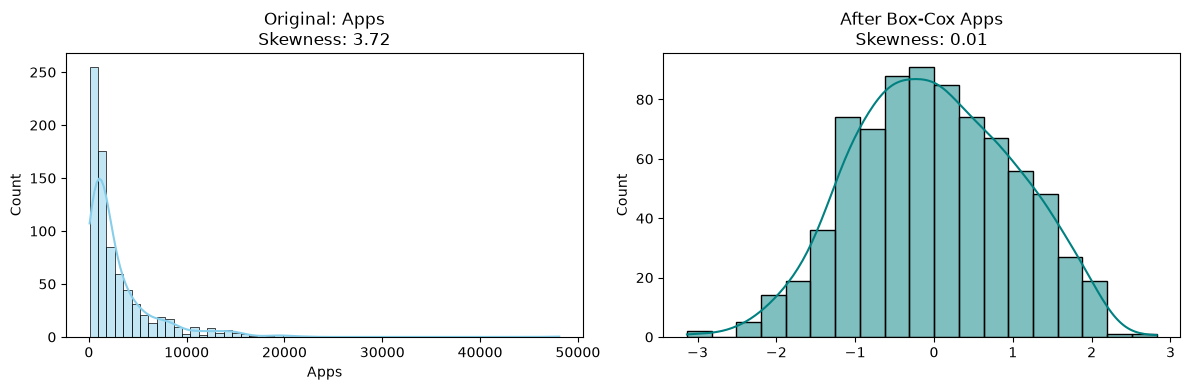

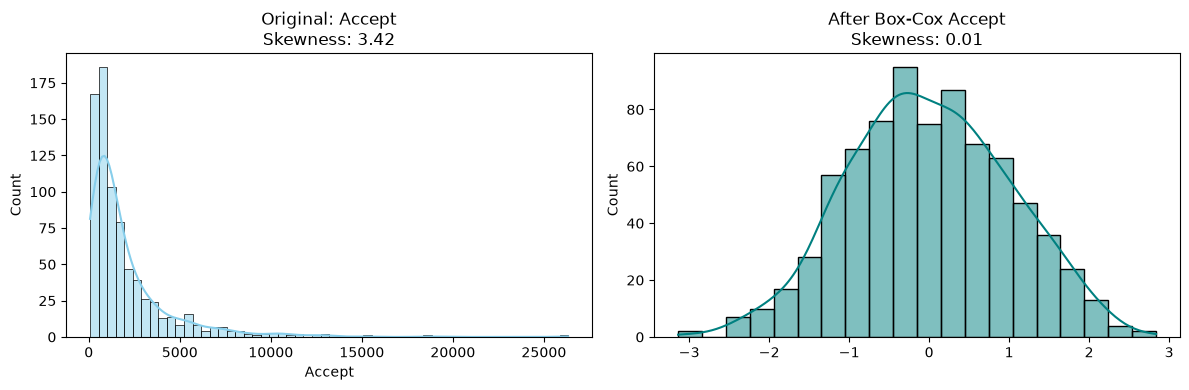

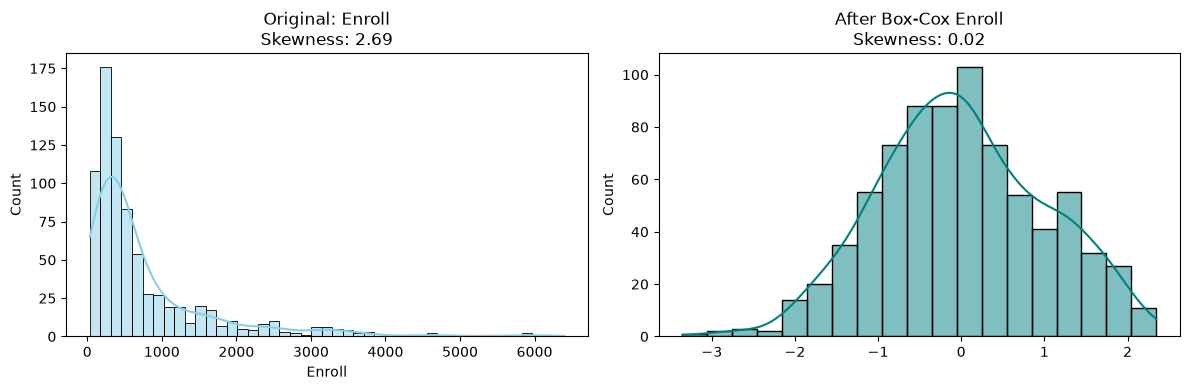

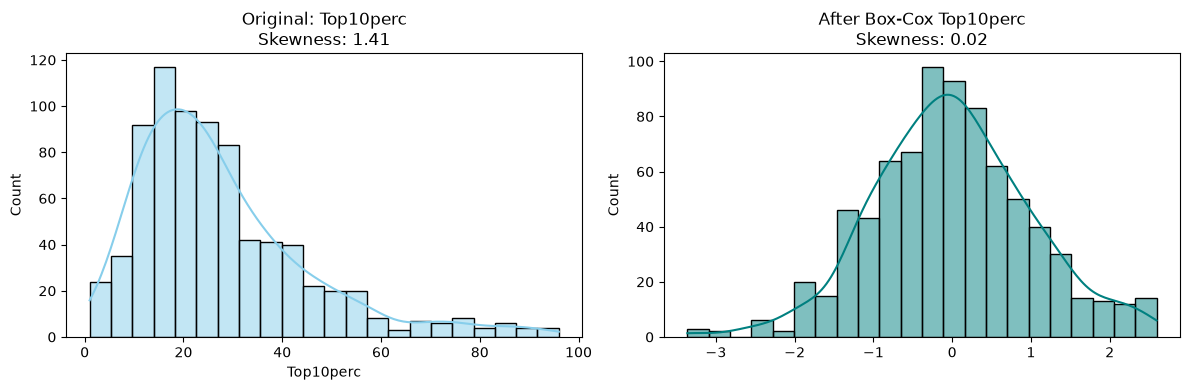

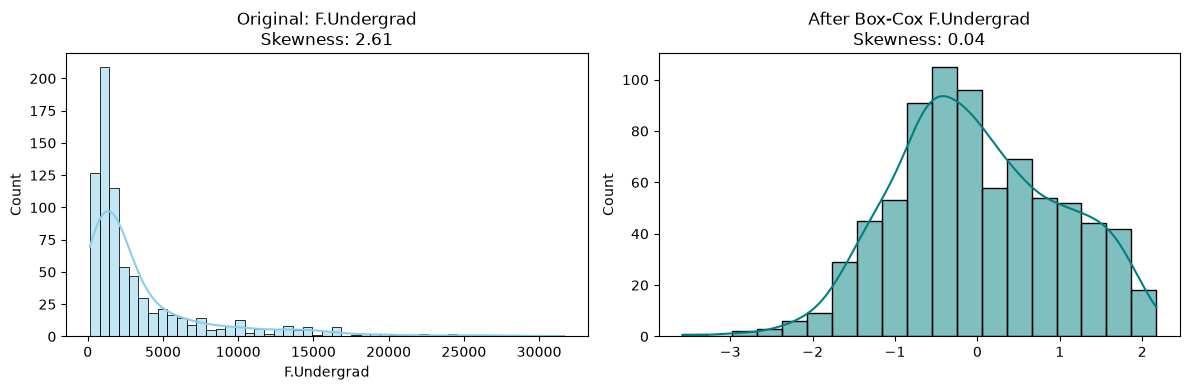

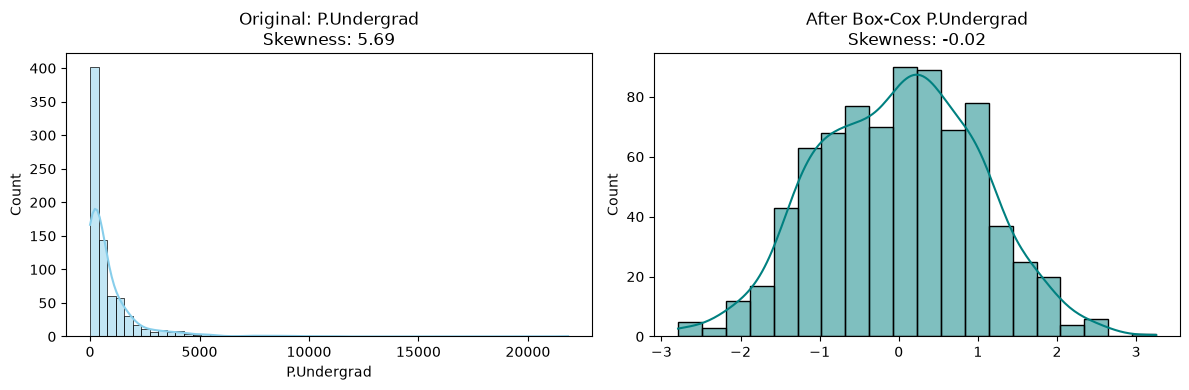

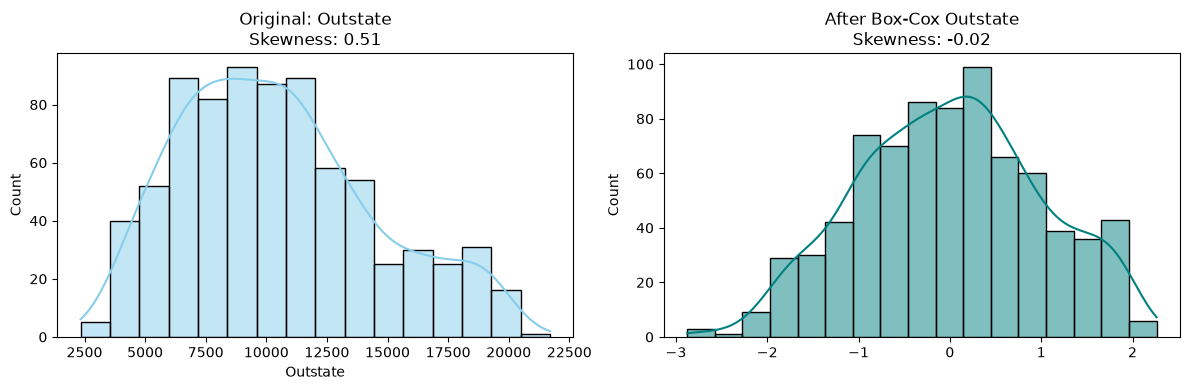

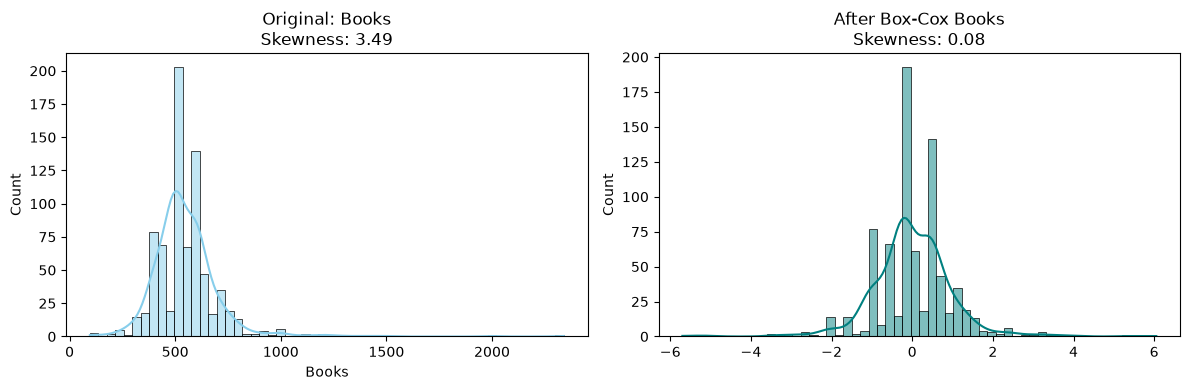

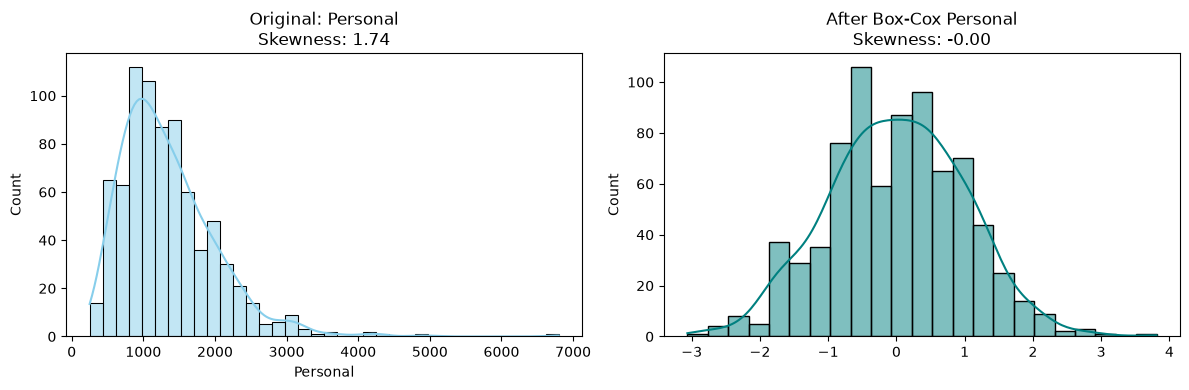

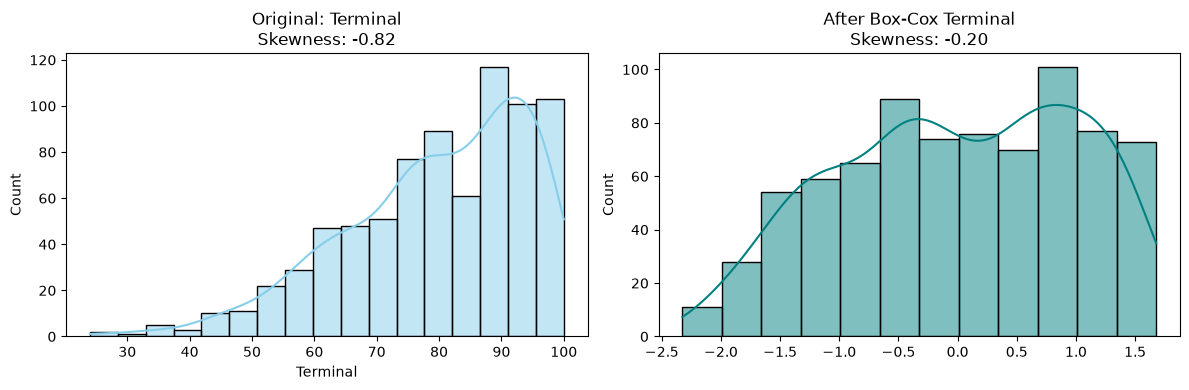

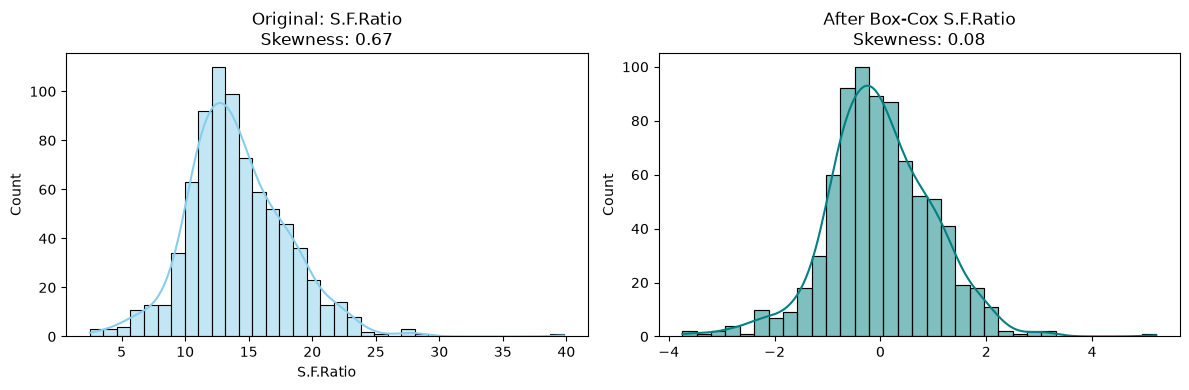

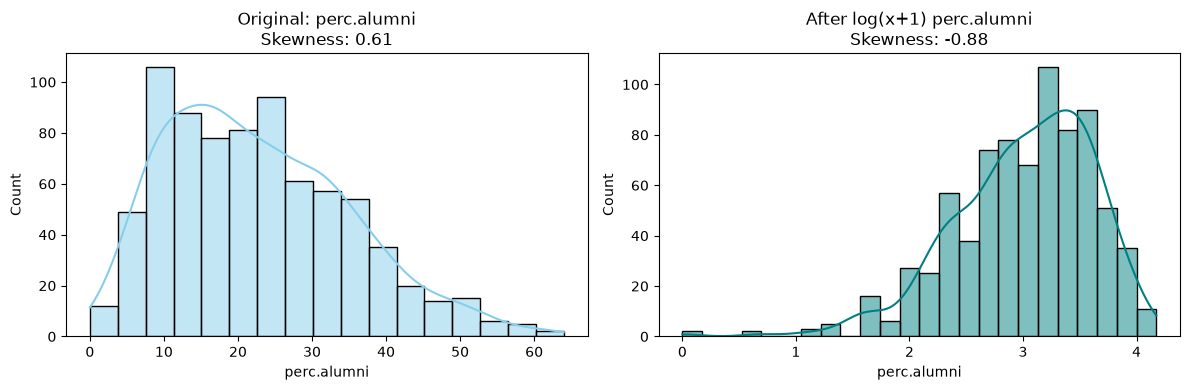

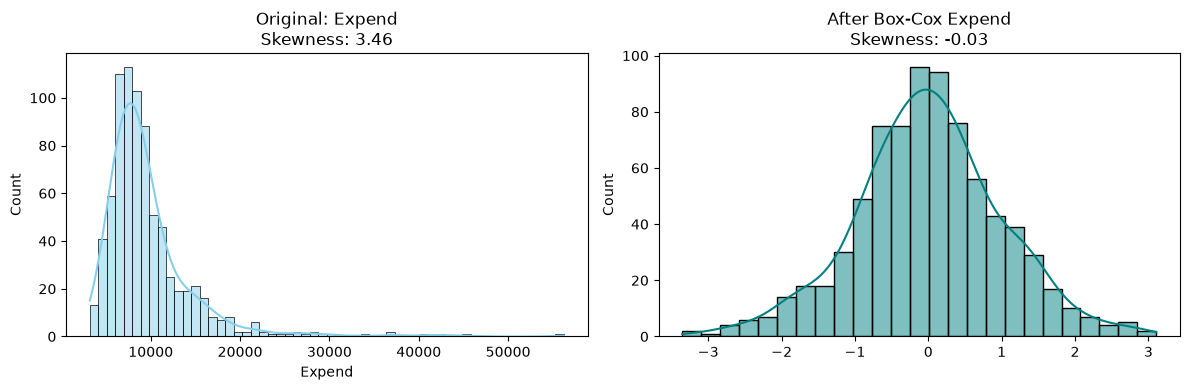

In [19]:
# Your code here
plot_transformations(df_c,skew_table)

In [20]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [21]:
trans_cols = []

# Your code here 
cols_to_transform = skew_table[skew_table['Recommended Transformation'] != 'None needed']['Feature']
for col in cols_to_transform:
    
    if df_c[col].min() > 0:
        pt = PowerTransformer(method='box-cox')
        transformed_data = pt.fit_transform(df_c[[col]]).reshape(-1)
        
    elif (df_c[col] >= 0).all():
        transformed_data = np.log1p(df_c[col]) 
        
    else:
        pt = PowerTransformer(method='yeo-johnson')
        transformed_data = pt.fit_transform(df_c[[col]]).reshape(-1)
    
    
    new_col_name = f"{col}_transformed"
    df_c[new_col_name] = transformed_data
    trans_cols.append(new_col_name)

trans_cols

['Apps_transformed',
 'Accept_transformed',
 'Enroll_transformed',
 'Top10perc_transformed',
 'F.Undergrad_transformed',
 'P.Undergrad_transformed',
 'Outstate_transformed',
 'Books_transformed',
 'Personal_transformed',
 'Terminal_transformed',
 'S.F.Ratio_transformed',
 'perc.alumni_transformed',
 'Expend_transformed']

## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [22]:
# Your code here 
df_c['Accept_Rate']=df_c['Accept']/df_c['Apps']

#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [23]:
# Your code here 
df_c['Outstate_Tier']=pd.cut(df_c['Outstate'],bins=[0, 10000, 13000, float('inf')],labels=['Low', 'Medium', 'High'])

#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [24]:
# Your code here 
df_c['Outstate_Tier_Encoded']=df_c['Outstate_Tier'].map({'Low':0,'Medium':1,'High':2}).astype(int)

#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [25]:
# Your code here 
df_c['Private_Encoded']=df_c['Private'].map({'No':0,'Yes':1})

## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [26]:
df_c.select_dtypes(include='number').columns

Index(['Apps', 'Accept', 'Enroll', 'Top10perc', 'Top25perc', 'F.Undergrad',
       'P.Undergrad', 'Outstate', 'Room.Board', 'Books', 'Personal',
       'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend', 'Grad.Rate',
       'Apps_transformed', 'Accept_transformed', 'Enroll_transformed',
       'Top10perc_transformed', 'F.Undergrad_transformed',
       'P.Undergrad_transformed', 'Outstate_transformed', 'Books_transformed',
       'Personal_transformed', 'Terminal_transformed', 'S.F.Ratio_transformed',
       'perc.alumni_transformed', 'Expend_transformed', 'Accept_Rate',
       'Outstate_Tier_Encoded', 'Private_Encoded'],
      dtype='str')

In [27]:
cols_to_scale = ['Apps_transformed', 'Accept_transformed',
                 'Enroll_transformed','Top10perc_transformed',
                 'F.Undergrad_transformed','P.Undergrad_transformed',
                 'Outstate_transformed','Books_transformed',
       'Personal_transformed', 'Terminal_transformed',
                 'S.F.Ratio_transformed','perc.alumni_transformed',
                 'Expend_transformed', 'Accept_Rate',
                 'Outstate_Tier_Encoded','Private_Encoded']

# Your code here 
ss=StandardScaler()
for i in cols_to_scale:
    col_s=f"{i}_scaled"
    df_c[col_s]=ss.fit_transform(df_c[[i]])

#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

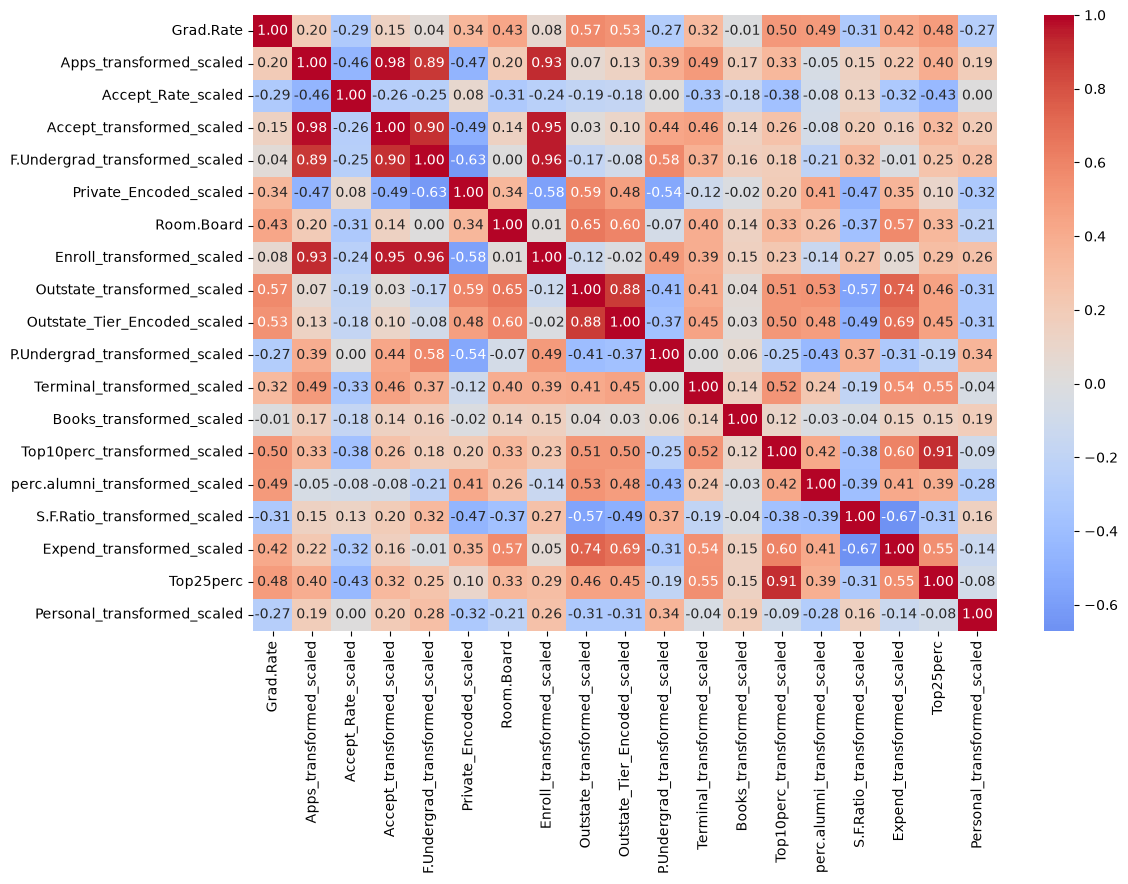

In [28]:
# Your code here 
all_scaled_cols = [c for c in df_c.columns if c.endswith('_scaled')]

extra_cols = ['Grad.Rate', 'Room.Board', 'Top25perc'] 
final_cols = list(set(all_scaled_cols + extra_cols))

plt.figure(figsize=(12, 8))
sns.heatmap(df_c[final_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.show()

__**Most related features with Grad.RAte are:\
Outstate_transformed_scaled with 0.57, then Top10perc_transformed_scaled with 0.49, \
then perc.alumni_transformed with 0.5**__

In [29]:
corr_matrix = df_c[final_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [column for column in upper.columns if any(upper[column] >= 0.85)]

print("Highly correlated columns to drop:", to_drop)

df_cleaned = df_c.drop(columns=to_drop)

Highly correlated columns to drop: ['Accept_transformed_scaled', 'F.Undergrad_transformed_scaled', 'Enroll_transformed_scaled', 'Outstate_Tier_Encoded_scaled', 'Top25perc']


## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [30]:
# Your code here
y=df_c['Grad.Rate']

#### 15. Fit a linear regression using the raw predictors


In [31]:
untrans_predictors = df_c[[ 'Accept', 'Top25perc','Room.Board',
         'Books', 'Personal',
       'Terminal', 'S.F.Ratio', 'perc.alumni', 'Expend','Accept_Rate',
       'Private_Encoded']]
# Your code here 
X_train,X_test,y_train,y_test=train_test_split(untrans_predictors,y,test_size=0.2,random_state=42)
model1=LinearRegression()
model1.fit(X_train,y_train)
r2_untran=r2_score(y_test,model1.predict(X_test))


#### 16. Fit the same model using the log-transformed predictors

In [32]:
trans_predictors =df_c[[ 'Accept_transformed_scaled', 'Top25perc',
                         'Room.Board','Books_transformed_scaled',
                         'Personal_transformed_scaled','Terminal_transformed_scaled',
                         'S.F.Ratio_transformed_scaled', 'perc.alumni_transformed_scaled',
                         'Expend_transformed_scaled','Accept_Rate_scaled',
                         'Private_Encoded_scaled']]

# Your code here 
Xs_train,Xs_test,ys_train,ys_test=train_test_split(trans_predictors,y,test_size=0.2,random_state=42)
model2=LinearRegression()
model2.fit(Xs_train,y_train)
r2_tran=r2_score(y_test,model2.predict(Xs_test))

#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [34]:
# Your code here 
print(f" R\u00B2 of untrasformed features is: {r2_untran} \n while the R\u00B2 of transformed features is: {r2_tran}")

 R² of untrasformed features is: 0.43585829024436207 
 while the R² of transformed features is: 0.470629454250167


**It appears there is about 4% improvent in the accuracy due the transformation technique**

#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [46]:
# Your code here
cols_to_remove = [
    'Apps', 'Accept', 'Enroll', 'Top10perc', 'F.Undergrad', 'P.Undergrad',
    'Outstate', 'Books', 'Personal', 'PhD', 'Terminal', 'S.F.Ratio', 
    'perc.alumni', 'Expend', 'Accept_Rate',
    'Apps_transformed', 'Accept_transformed', 'Enroll_transformed', 
    'Top10perc_transformed', 'F.Undergrad_transformed', 'P.Undergrad_transformed',
    'Outstate_transformed', 'Books_transformed', 'Personal_transformed',
    'Terminal_transformed', 'S.F.Ratio_transformed', 'perc.alumni_transformed', 
    'Expend_transformed', 'Outstate_Tier_Encoded', 'Private_Encoded'
]

df_scaled= df_cleaned.drop(columns=[c for c in cols_to_remove if c in df_cleaned.columns]).reset_index(drop=True)

In [47]:
df_scaled.to_csv('college_transformed.csv')